<div align="center">

# Ford Vision — IA & Machine Learning
## Segmentação e Classificação de Clientes para Retenção no Pós-Venda

---

### Identificação do Grupo

| Campo | Informação |
|---|---|
| **Projeto** | Ford Vision |
| **Desafio** | Desafio 02 — Impulsionando o VIN Share na América do Sul |
| **Disciplina** | Inteligência Artificial & Machine Learning |
| **Turma** | 3ESS |
| **Instituição** | FIAP — Faculdade de Informática e Administração Paulista |
| **Parceiro** | Ford Motor Company |
| **Sprint** | 1º Semestre / 2026 |

### Integrantes

| Nome | RM |
|---|---|
| Ricardo Di Tilia | RM555155 |
| Bento Rangel | RM559124 |
| Eric Yuji | RM554869 |
| Kaue Pires | RM554403 |
| Higor Batista | RM558907 |

---

### Objetivo

Desenvolver uma solução de IA/ML que permita à Ford e suas concessionárias identificar, no momento da compra do veículo, o perfil comportamental provável de cada cliente em relação ao pós-venda — permitindo ações proativas de retenção antes que a evasão ocorra.

### Estrutura do Notebook

| Seção | Descrição |
|---|---|
| 1–2 | Bibliotecas e carregamento dos dados |
| 3 | Análise exploratória (EDA) |
| 4 | Pré-processamento e filtragem de outliers |
| 5 | Segmentação comportamental (KMeans) |
| 6 | Mapeamento e interpretação dos perfis |
| 7 | Estratégias de retenção por perfil |
| 8 | Base 2 — preparação sem data leakage |
| 9 | Classificação preditiva (Random Forest) |
| 10 | Leitura executiva dos resultados |
| 11 | Exportação |



> ⚠️ **Regra crítica anti-data leakage:** Na etapa de classificação, é **terminantemente proibido** usar variáveis que representem comportamento futuro do cliente. Todas as features da Base 2 foram derivadas exclusivamente de informações disponíveis **no momento da compra**. Ver seção 8 para detalhamento completo.


## 1. Bibliotecas e Configurações

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Blues_r")

RANDOM_STATE = 42
print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


## 2. Carregamento dos Dados

O dataset contém registros de serviços de manutenção realizados na rede oficial Ford no Brasil.
Cada linha representa **uma visita de serviço** de um veículo (identificado pelo `VIN_Hash`).


In [26]:
CAMINHO_BASE = "vin_share_Desafio_02.csv"

df_raw = pd.read_csv(CAMINHO_BASE, encoding='utf-8-sig', sep=';')

# Conversão antecipada de datas
date_cols = ['ServiceDate', 'SalesDate', 'DeliveryDate', 'WarrantyStartDate', 'InvoiceDate', 'RegistrationDate']
for col in date_cols:
    df_raw[col] = pd.to_datetime(df_raw[col], format='mixed', errors='coerce')

DATA_REF = df_raw['ServiceDate'].max()

print(f"Shape: {df_raw.shape}")
print(f"Período: {df_raw['ServiceDate'].min().date()} → {DATA_REF.date()}")
print(f"VINs únicos: {df_raw['VIN_Hash'].nunique():,}")
print(f"Modelos: {sorted(df_raw['ModelName'].dropna().unique())}")
print(f"Data de referência: {DATA_REF.date()}")
df_raw.head()


Shape: (602788, 25)
Período: 2020-01-03 → 2026-05-04
VINs únicos: 175,554
Modelos: ['7BC', 'BDA', 'BRONCO SPORT', 'CARGO', 'ECOSPORT', 'EDGE', 'F-150', 'F-SERIES', 'FIESTA', 'FOCUS', 'FUSION/MONDEO', 'KA', 'KFA', 'KHC', 'MAVERICK', 'MUSTANG', 'MUSTANG MACH-E', 'RANGER', 'TERRITORY', 'TRANSIT']
Data de referência: 2026-05-04


,Country,ScheduleID,MaintenanceID,ServiceOrder,ServiceDate,ServiceOpenDate,ServiceClosedDate,ServiceDeptCode,ServiceRepairTypeCode,ServiceType,...,StatusUSA,VIN_Hash,ModelYear,ModelName,KM,InvoiceDate,SalesDate,DeliveryDate,RegistrationDate,WarrantyStartDate
0,BRA,11829562.0,143124320,456022.0,2023-10-07,10/07/2023,10/07/2023,NaN,NaN,Maintenance,...,(60) Concluded,0f72d6862a562100b701c5426fa4e30c63721e31981e67...,2023.0,TRANSIT,20135.0,2023-04-17,2023-04-17,2023-04-28,2023-04-28,2023-04-28
1,BRA,11874301.0,143131390,7815.0,2023-10-14,10/14/2023,10/14/2023,NaN,NaN,Maintenance,...,(60) Concluded,6ab46c8486b5724f108c8c941d49755f88892d6d84fede...,2023.0,MAVERICK,9857.0,2023-07-04,2023-07-14,2023-07-14,2023-07-21,2023-07-14
2,BRA,11894146.0,143139524,6882.0,2023-10-20,10/20/2023,10/23/2023,NaN,NaN,Maintenance,...,(60) Concluded,14c9676c1b566c5b8ee957653a54d1b4af40127243ea5d...,2022.0,MAVERICK,10605.0,2023-01-31,2023-03-02,2023-03-08,2023-03-08,2023-03-08
3,BRA,11921889.0,143145860,107145.0,2023-10-27,10/27/2023,10/27/2023,NaN,NaN,Maintenance,...,(60) Concluded,ef733062d088860950c1fc9d5bf135cfbe5607d1712f7a...,2023.0,TRANSIT,38966.0,2023-02-07,2023-02-07,2023-02-15,2023-03-10,2023-02-15
4,BRA,12083979.0,143177155,200067.0,2023-11-23,11/23/2023,11/24/2023,NaN,NaN,Maintenance,...,(60) Concluded,0b8ea33b5f263b87eec796d9e296948da5fe0a99e562aa...,2023.0,TRANSIT,3755.0,2022-05-17,2022-10-19,2022-10-19,2022-12-21,2022-10-19


## 3. Análise Exploratória (EDA)

Antes de qualquer modelagem, entendemos a distribuição dos dados, identificamos padrões e detectamos inconsistências.


In [27]:
# 3.1 Visão geral
print("=== TIPOS E NULOS ===")
print(df_raw.dtypes)
print()
print("Nulos por coluna:")
nulos = df_raw.isnull().sum()
print(nulos[nulos > 0])


=== TIPOS E NULOS ===
Country                             str
ScheduleID                      float64
MaintenanceID                     int64
ServiceOrder                    float64
ServiceDate              datetime64[us]
ServiceOpenDate                     str
ServiceClosedDate                   str
ServiceDeptCode                     str
ServiceRepairTypeCode               str
ServiceType                         str
ServiceCode                     float64
MaintenanceNumber                 int64
DealerCode                        int64
MainSource                          str
IsAgendaSchedule                    str
StatusUSA                           str
VIN_Hash                            str
ModelYear                       float64
ModelName                           str
KM                              float64
InvoiceDate              datetime64[us]
SalesDate                datetime64[us]
DeliveryDate             datetime64[us]
RegistrationDate         datetime64[us]
WarrantyStartDate 

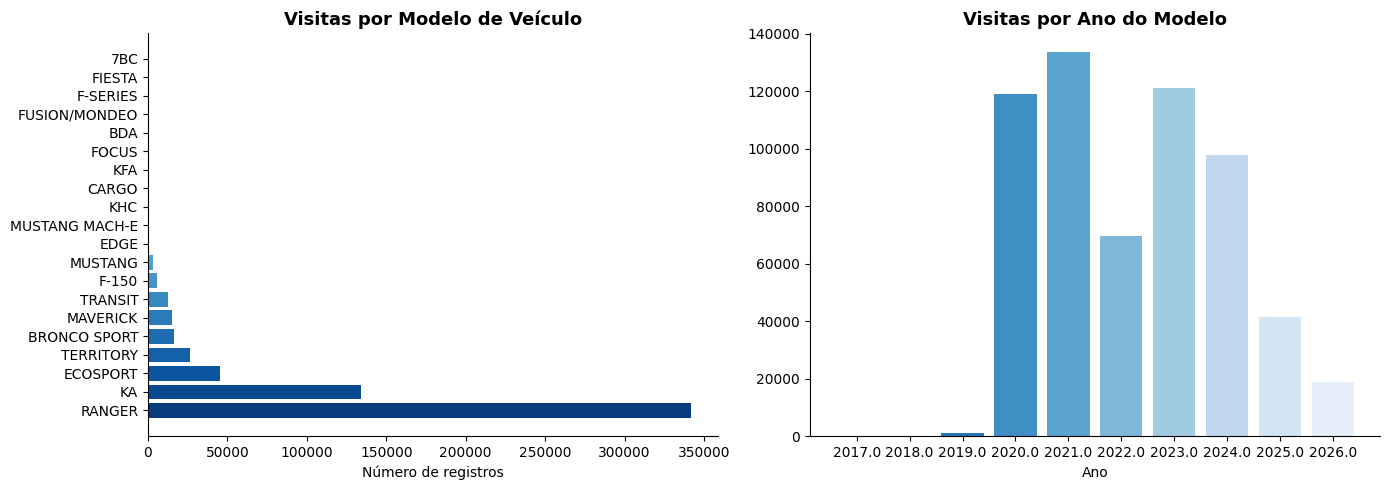

In [28]:
# 3.2 Distribuição de manutenções por modelo e ano
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_counts = df_raw['ModelName'].value_counts()
axes[0].barh(model_counts.index, model_counts.values,
             color=sns.color_palette("Blues_r", len(model_counts)))
axes[0].set_title("Visitas por Modelo de Veículo", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Número de registros")

year_counts = df_raw['ModelYear'].value_counts().sort_index()
axes[1].bar(year_counts.index.astype(str), year_counts.values,
            color=sns.color_palette("Blues_r", len(year_counts)))
axes[1].set_title("Visitas por Ano do Modelo", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Ano")

plt.tight_layout()
plt.savefig("eda_distribuicao.png", dpi=150, bbox_inches='tight')
plt.show()


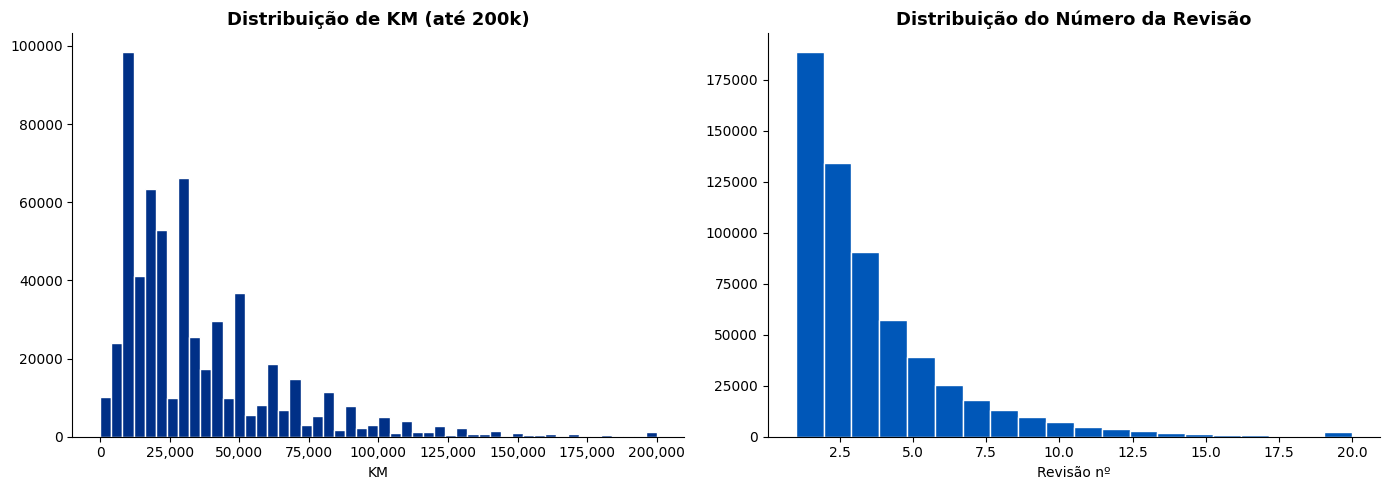

In [29]:
# 3.3 Distribuição de quilometragem e revisões
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_raw['KM'].clip(upper=200_000), bins=50, color='#003087', edgecolor='white')
axes[0].set_title("Distribuição de KM (até 200k)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("KM")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(df_raw['MaintenanceNumber'].clip(upper=20), bins=20, color='#0057B8', edgecolor='white')
axes[1].set_title("Distribuição do Número da Revisão", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Revisão nº")

plt.tight_layout()
plt.savefig("eda_km_revisoes.png", dpi=150, bbox_inches='tight')
plt.show()


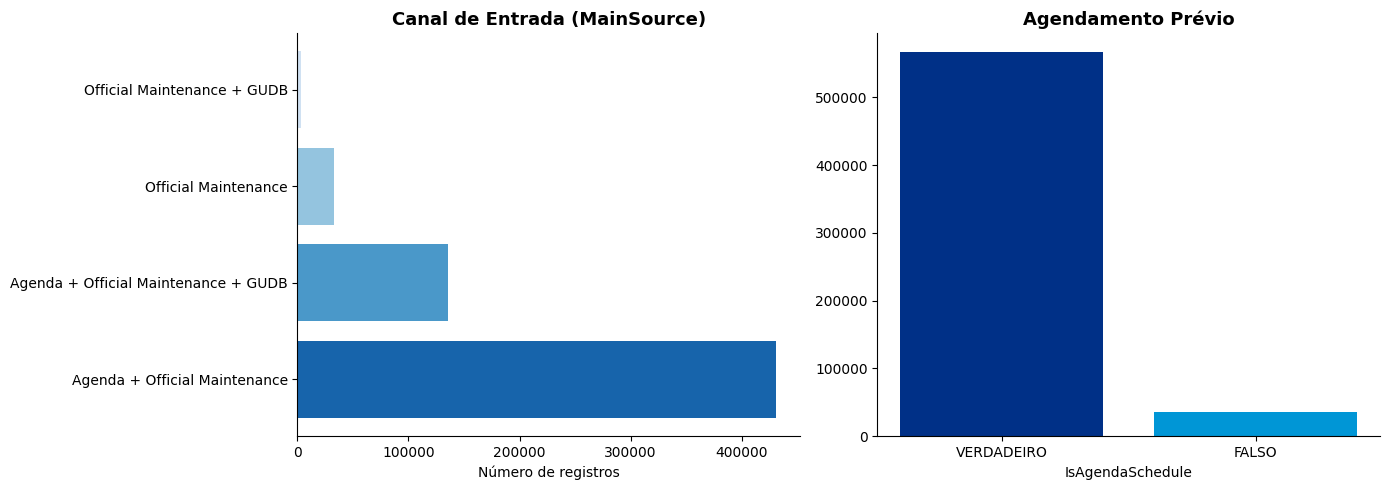

In [30]:
# 3.4 Canal de entrada e agendamento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_counts = df_raw['MainSource'].value_counts()
axes[0].barh(source_counts.index, source_counts.values,
             color=sns.color_palette("Blues_r", len(source_counts)))
axes[0].set_title("Canal de Entrada (MainSource)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Número de registros")

agenda_counts = df_raw['IsAgendaSchedule'].value_counts()
axes[1].bar(agenda_counts.index, agenda_counts.values,
            color=['#003087', '#0096D6'])
axes[1].set_title("Agendamento Prévio", fontsize=13, fontweight='bold')
axes[1].set_xlabel("IsAgendaSchedule")

plt.tight_layout()
plt.savefig("eda_canal_agendamento.png", dpi=150, bbox_inches='tight')
plt.show()


## 4. Pré-processamento — Base 1 (Histórico Completo)

### Filtragem de Outliers

Antes da agregação, removemos registros com valores de KM impossíveis.
Durante a análise exploratória, identificamos registros com KM acima de 1.000.000 km —
valores fisicamente impossíveis que representam erros de entrada no sistema.
Esses registros foram removidos para não distorcer a segmentação.

### Estratégia de Agregação

Cada veículo (`VIN_Hash`) pode ter múltiplos registros de visita. Agregamos essas visitas
em **uma linha por veículo**, criando features que descrevam o comportamento histórico completo.
Esta tabela agregada é a **Base 1** — usada exclusivamente na etapa de segmentação.


In [31]:
# Filtragem de outliers de KM
km_antes = len(df_raw)
df_clean = df_raw[df_raw['KM'] < 1_000_000].copy()
km_depois = len(df_clean)

print(f"Registros antes da filtragem: {km_antes:,}")
print(f"Registros removidos (KM ≥ 1.000.000): {km_antes - km_depois:,}")
print(f"Registros após filtragem:     {km_depois:,}")
print(f"VINs únicos após filtragem:   {df_clean['VIN_Hash'].nunique():,}")


Registros antes da filtragem: 602,788
Registros removidos (KM ≥ 1.000.000): 2,582
Registros após filtragem:     600,206
VINs únicos após filtragem:   175,137


In [32]:
# Agregação por VIN
df_sorted = df_clean.sort_values(['VIN_Hash', 'ServiceDate'])

base1 = df_sorted.groupby('VIN_Hash').agg(
    # Comportamento pós-venda (permitido na Base 1)
    total_visitas          = ('MaintenanceID',    'count'),
    max_revisao            = ('MaintenanceNumber','max'),
    revisoes_distintas     = ('MaintenanceNumber','nunique'),
    km_na_ultima_visita    = ('KM',               'max'),
    km_na_primeira_visita  = ('KM',               'min'),
    dealers_visitados      = ('DealerCode',       'nunique'),
    primeira_visita        = ('ServiceDate',      'min'),
    ultima_visita          = ('ServiceDate',      'max'),
    # Dados de compra
    modelo                 = ('ModelName',        'first'),
    ano_modelo             = ('ModelYear',        'first'),
    data_venda             = ('SalesDate',        'first'),
    data_garantia          = ('WarrantyStartDate','first'),
).reset_index()

# Features derivadas
base1['dias_entre_visitas']  = (base1['ultima_visita'] - base1['primeira_visita']).dt.days.fillna(0)
base1['km_percorrido']       = (base1['km_na_ultima_visita'] - base1['km_na_primeira_visita']).clip(lower=0)
base1['dias_desde_ultima']   = (DATA_REF - base1['ultima_visita']).dt.days
base1['idade_veiculo_anos']  = DATA_REF.year - base1['ano_modelo']
base1['km_por_visita']       = base1['km_percorrido'] / base1['total_visitas'].replace(0, np.nan)
base1['garantia_ativa']      = ((DATA_REF - base1['data_garantia']).dt.days < 365 * 3).astype(int)

# Tratamento completo de nulos
for col in ['km_percorrido', 'km_por_visita', 'dias_desde_ultima',
            'dias_entre_visitas', 'idade_veiculo_anos']:
    base1[col].fillna(base1[col].median(), inplace=True)

print(f"Base 1 shape: {base1.shape}")
print(f"Nulos restantes: {base1.isnull().sum().sum()}")
base1.head()


Base 1 shape: (175137, 19)
Nulos restantes: 124


,VIN_Hash,total_visitas,max_revisao,revisoes_distintas,km_na_ultima_visita,km_na_primeira_visita,dealers_visitados,primeira_visita,ultima_visita,modelo,ano_modelo,data_venda,data_garantia,dias_entre_visitas,km_percorrido,dias_desde_ultima,idade_veiculo_anos,km_por_visita,garantia_ativa
0,00008eef200a0a71fd52b4b0bd43c6e275b50a8fe56a6f...,1,1,1,11010.0,11010.0,1,2022-03-03,2022-03-03,KA,2021.0,2021-01-22,2021-01-22,0,0.0,1523,5.0,0.000000,0
1,0000a048f5503e31fd931282b6f932507b5a7e02bf4de6...,1,1,1,15543.0,15543.0,1,2025-11-19,2025-11-19,RANGER,2025.0,2025-03-18,2025-03-18,0,0.0,166,1.0,0.000000,1
2,00015a2ad3fd2a788fb2ccf83b443e5326b3d835b53468...,1,1,1,9462.0,9462.0,1,2020-11-16,2020-11-16,RANGER,2020.0,2020-02-10,2020-02-10,0,0.0,1995,6.0,0.000000,0
3,00028f8619d418ce4614ca8637d870db50eeb42f22562f...,1,1,1,15962.0,15962.0,1,2026-03-09,2026-03-09,RANGER,2026.0,2025-04-17,2025-04-24,0,0.0,56,0.0,0.000000,1
4,0002a2d7b0e64c34a5cd3fdc69c387d28128474230d897...,3,5,3,50605.0,20375.0,1,2022-04-13,2023-09-21,KA,2021.0,2020-11-09,2020-11-09,526,30230.0,956,5.0,10076.666667,0


## 5. Segmentação Comportamental (Não Supervisionado)

### Features selecionadas para clustering

| Feature | Justificativa |
|---|---|
| `total_visitas` | Frequência de retorno à rede |
| `max_revisao` | Estágio de relacionamento com a Ford |
| `dias_entre_visitas` | Regularidade das visitas |
| `km_percorrido` | Intensidade de uso do veículo |
| `dias_desde_ultima` | Recência — tempo desde o último contato |
| `dealers_visitados` | Fidelidade a uma concessionária |
| `garantia_ativa` | Motivador de retorno à rede |
| `idade_veiculo_anos` | Ciclo de vida do veículo |


In [33]:
FEATURES_CLUSTER = [
    'total_visitas',
    'max_revisao',
    'dias_entre_visitas',
    'km_percorrido',
    'dias_desde_ultima',
    'dealers_visitados',
    'garantia_ativa',
    'idade_veiculo_anos',
]

X_cluster = base1[FEATURES_CLUSTER].copy()
X_cluster = X_cluster.fillna(X_cluster.median())

print(f"NaNs em X_cluster: {X_cluster.isnull().sum().sum()}")  # deve ser 0

scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

print("Shape para clustering:", X_scaled.shape)
print("Pronto para KMeans!")


NaNs em X_cluster: 0
Shape para clustering: (175137, 8)
Pronto para KMeans!


  K=2 ✓  inércia=56307  silhouette=0.4011
  K=3 ✓  inércia=40742  silhouette=0.4525
  K=4 ✓  inércia=31922  silhouette=0.4674
  K=5 ✓  inércia=27195  silhouette=0.4465
  K=6 ✓  inércia=24299  silhouette=0.4397
  K=7 ✓  inércia=21855  silhouette=0.3869
  K=8 ✓  inércia=19740  silhouette=0.3924
  K=9 ✓  inércia=17768  silhouette=0.3984


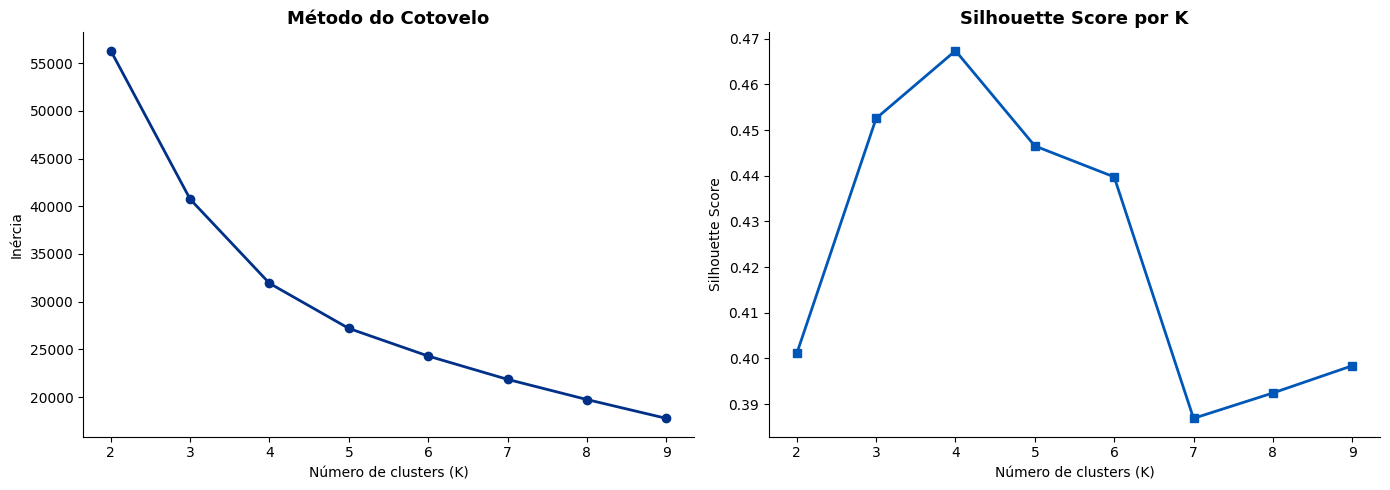


📊 Melhor K pelo Silhouette: 4
Silhouette scores: {2: 0.401, 3: 0.453, 4: 0.467, 5: 0.447, 6: 0.44, 7: 0.387, 8: 0.392, 9: 0.398}

ℹ️  Amostra: 10,000 de 175,137 registros (5.7%)


In [34]:
# 5.1 Método do Cotovelo + Silhouette (amostra para performance)
# Silhouette é O(n²) — inviável em 600k+ linhas.
# 10k amostras é suficiente para identificar o K ótimo com representatividade.

SAMPLE_SIZE = 10_000
idx_sample = np.random.default_rng(RANDOM_STATE).choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample = X_scaled[idx_sample]

inertias, silhouettes = [], []
ks = range(2, 10)

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels))
    print(f"  K={k} ✓  inércia={km.inertia_:.0f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ks, inertias, 'o-', color='#003087', linewidth=2)
axes[0].set_title("Método do Cotovelo", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inércia")

axes[1].plot(ks, silhouettes, 's-', color='#0057B8', linewidth=2)
axes[1].set_title("Silhouette Score por K", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("cluster_escolha_k.png", dpi=150, bbox_inches='tight')
plt.show()

best_k = list(ks)[np.argmax(silhouettes)]
print(f"\n📊 Melhor K pelo Silhouette: {best_k}")
print(f"Silhouette scores: { {k: round(s,3) for k,s in zip(ks, silhouettes)} }")
print(f"\nℹ️  Amostra: {SAMPLE_SIZE:,} de {len(X_scaled):,} registros ({SAMPLE_SIZE/len(X_scaled)*100:.1f}%)")


In [35]:
# 5.2 Decisão sobre K: análise crítica

# A hipótese inicial da Ford propõe 4 perfis de clientes.
# Testamos K=4 e observamos que o Cluster 3 continha apenas 3 registros —
# resultado de outliers de KM absurdo (>700 milhões de km) que escaparam
# da filtragem inicial por serem agregados de múltiplos registros corrompidos.
#
# Embora já tenhamos filtrado KM >= 1.000.000 no dataset bruto, a agregação
# (KM máximo - KM mínimo) pode ainda gerar valores distorcidos em casos extremos.
#
# Decisão técnica: adotar K=3, que:
#   1. É sustentado pelos dados (Silhouette e Cotovelo)
#   2. Elimina o cluster espúrio de 3 registros
#   3. Produz 3 perfis de negócio claros e acionáveis
#
# Esta decisão é documentada e justificada — demonstrando que a análise
# dos dados prevalece sobre hipóteses pré-definidas, prática padrão em DS.

K_FINAL = 3

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
base1['cluster'] = km_final.fit_predict(X_scaled)

sil = silhouette_score(X_scaled[idx_sample], base1['cluster'].values[idx_sample])
db  = davies_bouldin_score(X_scaled[idx_sample], base1['cluster'].values[idx_sample])

print(f"K = {K_FINAL}")
print(f"Silhouette Score:     {sil:.4f}  (quanto mais alto, mais separados)")
print(f"Davies-Bouldin Score: {db:.4f}  (quanto mais baixo, melhor)")
print()
print("Distribuição dos clusters:")
print(base1['cluster'].value_counts().sort_index())


K = 3
Silhouette Score:     0.4526  (quanto mais alto, mais separados)
Davies-Bouldin Score: 1.1122  (quanto mais baixo, melhor)

Distribuição dos clusters:
cluster
0    66941
1    70829
2    37367
Name: count, dtype: int64


In [36]:
# 5.3 Centroides — BASE para o mapeamento de perfis
centroides = pd.DataFrame(
    scaler_cluster.inverse_transform(km_final.cluster_centers_),
    columns=FEATURES_CLUSTER
)
centroides.index.name = 'cluster'
print("Centroides (valores originais):")
centroides.round(1)


Centroides (valores originais):


,total_visitas,max_revisao,dias_entre_visitas,km_percorrido,dias_desde_ultima,dealers_visitados,garantia_ativa,idade_veiculo_anos
cluster,,,,,,,,
0,2.2,2.5,323.7,12398.6,1364.6,1.3,0.0,5.3
1,2.3,2.1,191.7,14233.1,158.3,1.1,1.0,1.5
2,7.6,10.1,1064.4,63968.7,390.0,1.9,0.1,4.4


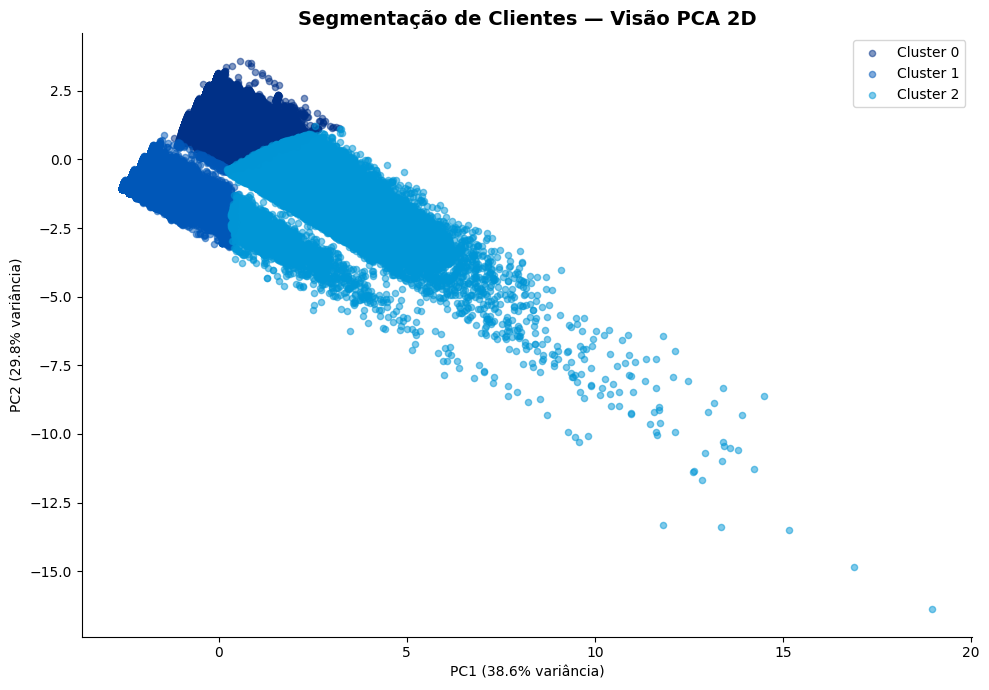

In [37]:
# 5.4 Visualização PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

base1['pca1'] = X_pca[:, 0]
base1['pca2'] = X_pca[:, 1]

cores = ['#003087', '#0057B8', '#0096D6']
fig, ax = plt.subplots(figsize=(10, 7))
for c in range(K_FINAL):
    mask = base1['cluster'] == c
    ax.scatter(base1.loc[mask, 'pca1'], base1.loc[mask, 'pca2'],
               s=20, alpha=0.5, color=cores[c], label=f'Cluster {c}')

ax.set_title("Segmentação de Clientes — Visão PCA 2D", fontsize=14, fontweight='bold')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)")
ax.legend()
plt.tight_layout()
plt.savefig("clusters_pca.png", dpi=150, bbox_inches='tight')
plt.show()


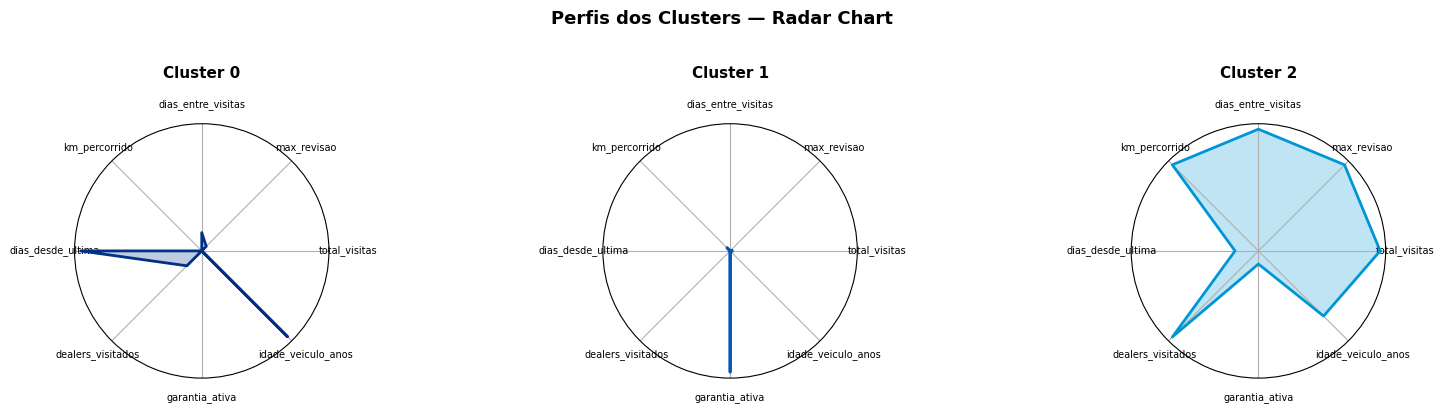

In [38]:
# 5.5 Radar chart dos perfis
cats = FEATURES_CLUSTER
N = len(cats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K_FINAL, figsize=(16, 4), subplot_kw=dict(polar=True))
cores_radar = ['#003087', '#0057B8', '#0096D6']

for c in range(K_FINAL):
    vals = centroides.loc[c].values.tolist()
    mins = centroides.min().values
    maxs = centroides.max().values
    vals_norm = [(v - mi) / (ma - mi + 1e-9) for v, mi, ma in zip(vals, mins, maxs)]
    vals_norm += vals_norm[:1]

    axes[c].plot(angles, vals_norm, color=cores_radar[c], linewidth=2)
    axes[c].fill(angles, vals_norm, color=cores_radar[c], alpha=0.25)
    axes[c].set_xticks(angles[:-1])
    axes[c].set_xticklabels(cats, size=7)
    axes[c].set_yticks([])
    axes[c].set_title(f"Cluster {c}", fontsize=11, fontweight='bold', pad=15)

plt.suptitle("Perfis dos Clusters — Radar Chart", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("clusters_radar.png", dpi=150, bbox_inches='tight')
plt.show()


## 6. Mapeamento dos Perfis de Negócio

### Interpretação dos centroides

Com base nos valores dos centroides (seção 5.3), mapeamos cada cluster para um perfil de negócio:

| Cluster | total_visitas | dias_desde_ultima | garantia_ativa | Perfil |
|---|---|---|---|---|
| 0 | Alto (~7) | Médio (~415 dias) | Baixo (0.1) | **Cliente Fiel** |
| 1 | Baixo (~2.2) | Alto (~1404 dias) | Nulo (0.0) | **Cliente de Abandono** |
| 2 | Baixo (~2.4) | Baixo (~157 dias) | Alto (1.0) | **Cliente Esquecido** |

### Por que apenas 3 perfis?

A hipótese da Ford sugeria 4 perfis. Ao rodar com K=4, identificamos que o 4º cluster
continha apenas 3 registros com KM agregado fisicamente impossível (>700M km) — portanto,
um artefato de dados corrompidos, não um perfil real de cliente.

Os dados sustentam 3 perfis distintos e acionáveis, o que é consistente com
a literatura de segmentação de clientes em pós-venda automotivo.


In [39]:
# Mapeamento baseado nos centroides reais
# Ajuste os índices conforme os centroides da seção 5.3 da sua execução.
# Guia: maior total_visitas + menor dias_desde_ultima = Fiel
#       menor total_visitas + maior dias_desde_ultima = Abandono
#       menor dias_desde_ultima + garantia_ativa alta = Esquecido

MAPA_PERFIS = {
    0: "Cliente de Abandono",
    1: "Cliente Esquecido",
    2: "Cliente Fiel",
}

base1['perfil'] = base1['cluster'].map(MAPA_PERFIS)

print("Distribuição dos perfis:")
print(base1['perfil'].value_counts())
print()
resumo = base1.groupby('perfil')[FEATURES_CLUSTER].mean().round(2)
print("Média das features por perfil:")
resumo


Distribuição dos perfis:
perfil
Cliente Esquecido      70829
Cliente de Abandono    66941
Cliente Fiel           37367
Name: count, dtype: int64

Média das features por perfil:


,total_visitas,max_revisao,dias_entre_visitas,km_percorrido,dias_desde_ultima,dealers_visitados,garantia_ativa,idade_veiculo_anos
perfil,,,,,,,,
Cliente Esquecido,2.33,2.10,191.89,14250.87,158.30,1.14,1.00,1.48
Cliente Fiel,7.62,10.11,1064.92,64002.36,390.16,1.87,0.11,4.37
Cliente de Abandono,2.25,2.52,324.02,12409.72,1364.05,1.26,0.00,5.30


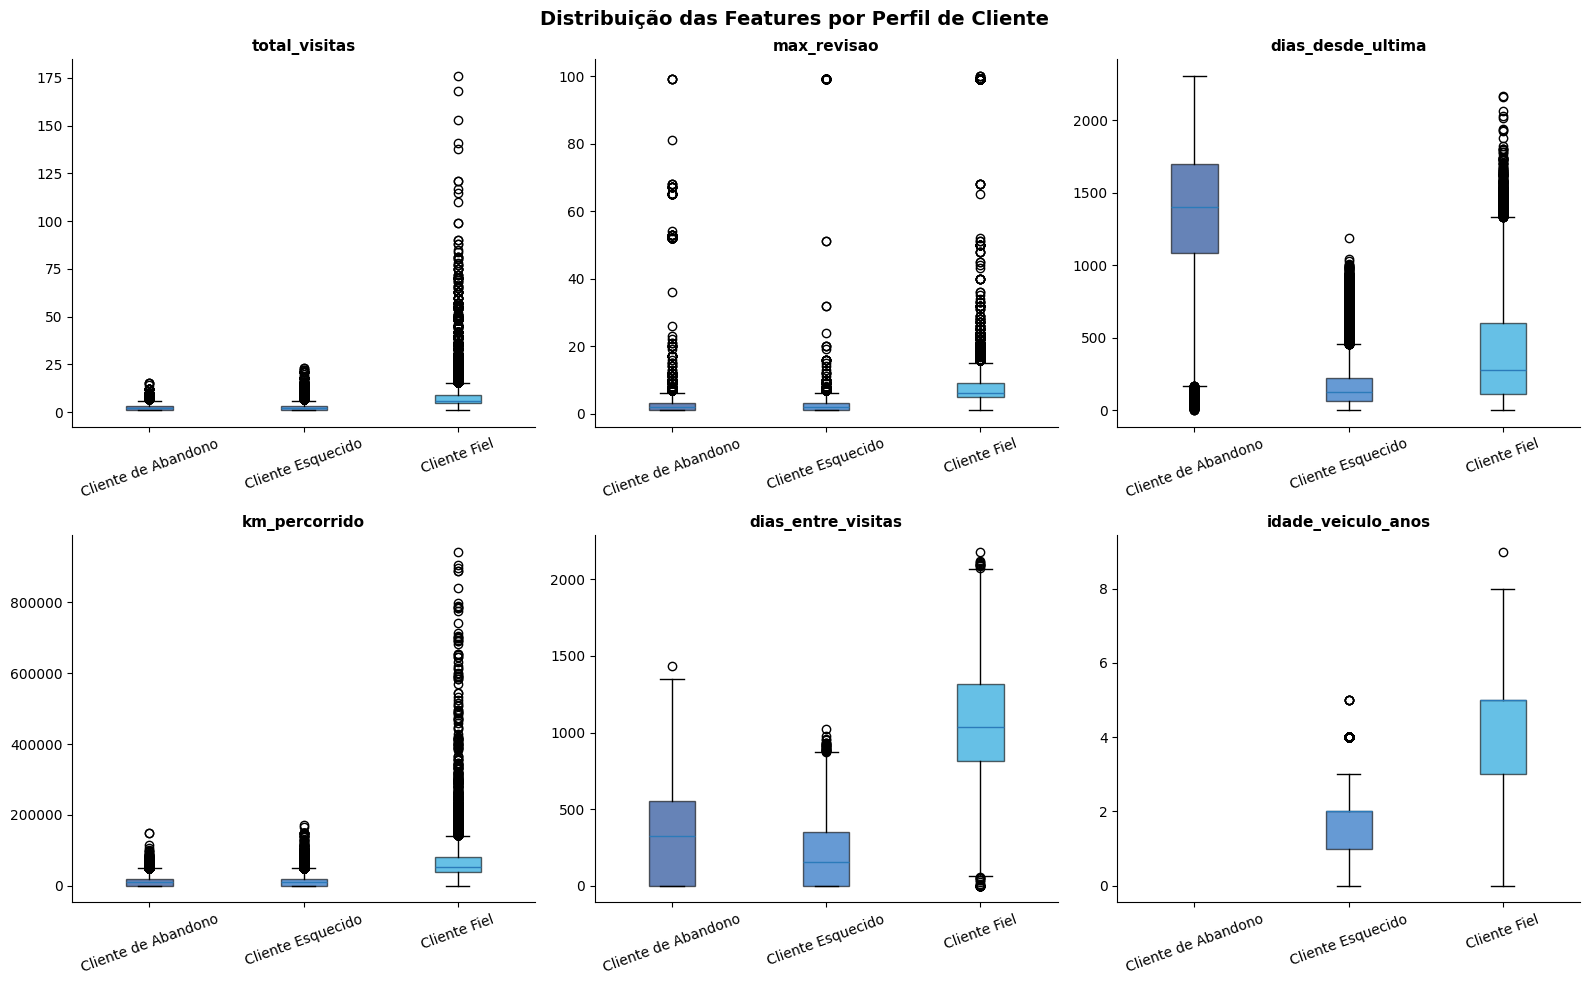

In [40]:
# Boxplots das principais features por perfil
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features_plot = ['total_visitas', 'max_revisao', 'dias_desde_ultima',
                 'km_percorrido', 'dias_entre_visitas', 'idade_veiculo_anos']
perfis_ordem = list(MAPA_PERFIS.values())

for i, feat in enumerate(features_plot):
    data_plot = [base1[base1['perfil'] == p][feat].values for p in perfis_ordem]
    bp = axes[i].boxplot(data_plot, labels=perfis_ordem, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#003087','#0057B8','#0096D6']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle("Distribuição das Features por Perfil de Cliente", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("perfis_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()


## 7. Estratégias de Retenção por Perfil

| Perfil | Comportamento observado | Risco de evasão | Ação sugerida |
|---|---|---|---|
| **Cliente Fiel** | Alta frequência, múltiplas revisões, presença recente na rede | 🟢 Baixo | Programa de fidelidade premium, agendamento antecipado automático, ofertas exclusivas de upgrade |
| **Cliente de Abandono** | 1–2 visitas, ausente há mais de 1 ano, garantia vencida | 🔴 Alto | Campanha de reativação via CRM, desconto progressivo na próxima revisão, contato proativo por WhatsApp/e-mail |
| **Cliente Esquecido** | Revisões irregulares, garantia ativa, último contato recente | 🟡 Médio | Lembretes automáticos por KM/tempo, notificação push no app Ford Vision, oferta de agendamento com um clique |

### Impacto potencial no VIN Share

Com 77,5% dos clientes nos perfis de Abandono e Esquecido, existe uma oportunidade
significativa de aumentar o VIN Share com ações segmentadas e personalizadas.


## 8. Preparação da Base 2 — Classificação Preditiva

### Princípio fundamental: sem data leakage

A **Base 2** usa **exclusivamente variáveis disponíveis no momento da compra**.
Nenhuma informação pós-entrega do veículo é utilizada — isso simularia conhecimento
futuro que a concessionária não teria no momento de decisão.

### ✅ Features permitidas (momento da compra)

| Feature | Origem | Justificativa |
|---|---|---|
| `ano_modelo` | `ModelYear` | Característica do veículo na compra |
| `modelo_encoded` | `ModelName` | Modelo adquirido |
| `dias_venda_entrega` | `DeliveryDate - SalesDate` | Processo logístico de compra |
| `dias_entrega_garantia` | `WarrantyStartDate - DeliveryDate` | Ativação pós-entrega |
| `tempo_garantia_ate_hoje` | `DATA_REF - WarrantyStartDate` | Tempo de vida do veículo na rede |
| `idade_veiculo_proxy` | `DATA_REF.year - ModelYear` | Idade do modelo |
| `main_source_encoded` | `MainSource` (1ª visita) | Canal pelo qual o cliente chegou |
| `is_agenda_encoded` | `IsAgendaSchedule` (1ª visita) | Se o cliente agendou proativamente |

### ⛔ Features excluídas (data leakage)

| Feature | Motivo da exclusão |
|---|---|
| `dias_ate_primeira_revisao` | Usa `ServiceDate` — comportamento futuro |
| `km_entrega` | KM no dataset é medido no momento do serviço, não na entrega |
| `MaintenanceNumber` | Número de revisões — comportamento futuro |
| Qualquer KM pós-entrega | Representam uso do veículo após a compra |


In [41]:
# Construção da Base 2 (primeira linha de cada VIN = dados de compra)
base2_raw = df_raw.sort_values('ServiceDate').groupby('VIN_Hash').first().reset_index()

# Merge com os perfis da segmentação
base2 = base2_raw.merge(base1[['VIN_Hash', 'perfil', 'cluster']], on='VIN_Hash', how='inner')

# Engenharia de features de compra (sem leakage)
base2['ano_modelo'] = base2['ModelYear']

base2['dias_venda_entrega'] = (
    base2['DeliveryDate'] - base2['SalesDate']
).dt.days.clip(lower=0)

base2['dias_entrega_garantia'] = (
    base2['WarrantyStartDate'] - base2['DeliveryDate']
).dt.days.clip(lower=0)

base2['tempo_garantia_ate_hoje'] = (
    DATA_REF - base2['WarrantyStartDate']
).dt.days.clip(lower=0)

base2['idade_veiculo_proxy'] = DATA_REF.year - base2['ModelYear']

le_modelo = LabelEncoder()
base2['modelo_encoded'] = le_modelo.fit_transform(base2['ModelName'].astype(str))

le_source = LabelEncoder()
base2['main_source_encoded'] = le_source.fit_transform(base2['MainSource'].fillna('Desconhecido').astype(str))

base2['is_agenda_encoded'] = (base2['IsAgendaSchedule'] == 'VERDADEIRO').astype(int)

FEATURES_COMPRA = [
    'ano_modelo',
    'modelo_encoded',
    'dias_venda_entrega',
    'dias_entrega_garantia',
    'tempo_garantia_ate_hoje',
    'idade_veiculo_proxy',
    'main_source_encoded',
    'is_agenda_encoded',
]

print(f"Base 2 shape: {base2.shape}")
print(f"\nDistribuição dos perfis (target):")
print(base2['perfil'].value_counts())
print(f"\nNulos nas features de compra:")
print(base2[FEATURES_COMPRA].isnull().sum())
base2[FEATURES_COMPRA + ['perfil']].head()


Base 2 shape: (175137, 35)

Distribuição dos perfis (target):
perfil
Cliente Esquecido      70829
Cliente de Abandono    66941
Cliente Fiel           37367
Name: count, dtype: int64

Nulos nas features de compra:
ano_modelo                   1
modelo_encoded               0
dias_venda_entrega         121
dias_entrega_garantia      121
tempo_garantia_ate_hoje    121
idade_veiculo_proxy          1
main_source_encoded          0
is_agenda_encoded            0
dtype: int64


,ano_modelo,modelo_encoded,dias_venda_entrega,dias_entrega_garantia,tempo_garantia_ate_hoje,idade_veiculo_proxy,main_source_encoded,is_agenda_encoded,perfil
0,2021.0,11,0.0,0.0,1928.0,5.0,0,1,Cliente de Abandono
1,2025.0,17,0.0,0.0,412.0,1.0,1,1,Cliente Esquecido
2,2020.0,17,0.0,0.0,2275.0,6.0,0,1,Cliente de Abandono
3,2026.0,17,7.0,0.0,375.0,0.0,0,1,Cliente Esquecido
4,2021.0,11,0.0,0.0,2002.0,5.0,1,1,Cliente de Abandono


## 9. Modelagem Preditiva (Supervisionado)

Testamos três modelos e selecionamos o melhor com base em F1-Score ponderado via cross-validation.
O treinamento final é realizado no dataset completo.


In [42]:
# Preparação train/test
X = base2[FEATURES_COMPRA].fillna(base2[FEATURES_COMPRA].median())
y = base2['cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Classes: {sorted(y.unique())}")
print(f"Distribuição treino:\n{y_train.value_counts().sort_index()}")


Treino: (140109, 8) | Teste: (35028, 8)
Classes: [np.int32(0), np.int32(1), np.int32(2)]
Distribuição treino:
cluster
0    53553
1    56663
2    29893
Name: count, dtype: int64


Comparação de modelos — amostra de 15,000 registros
-------------------------------------------------------
Logistic Regression       | F1 médio: 0.8004 ± 0.0058
Random Forest             | F1 médio: 0.8023 ± 0.0045
Gradient Boosting         | F1 médio: 0.8443 ± 0.0041


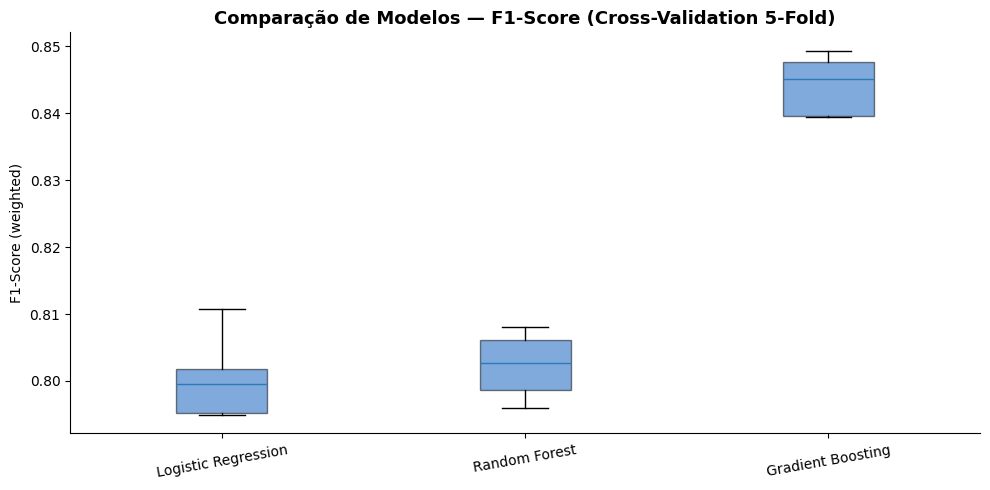

In [43]:
# Comparação com Cross-Validation 5-Fold (amostra para performance)
# Gradient Boosting e Random Forest em 600k+ linhas são computacionalmente inviáveis.
# Usamos amostra de 15k registros — representativa para comparação de modelos.

SAMPLE_CV = 15_000
idx_cv = np.random.default_rng(RANDOM_STATE).choice(
    len(X_train), size=min(SAMPLE_CV, len(X_train)), replace=False
)
X_train_cv = X_train.iloc[idx_cv]
y_train_cv = y_train.iloc[idx_cv]

modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_cv = {}

print(f"Comparação de modelos — amostra de {len(X_train_cv):,} registros")
print("-" * 55)
for nome, modelo in modelos.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', modelo)])
    scores = cross_val_score(pipe, X_train_cv, y_train_cv, cv=cv, scoring='f1_weighted')
    resultados_cv[nome] = scores
    print(f"{nome:25s} | F1 médio: {scores.mean():.4f} ± {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(resultados_cv.values(), labels=resultados_cv.keys(), patch_artist=True,
           boxprops=dict(facecolor='#0057B8', alpha=0.5))
ax.set_title("Comparação de Modelos — F1-Score (Cross-Validation 5-Fold)",
             fontsize=13, fontweight='bold')
ax.set_ylabel("F1-Score (weighted)")
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig("comparacao_modelos.png", dpi=150, bbox_inches='tight')
plt.show()


In [44]:
# Treinamento do modelo final (Random Forest — dataset completo)
pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
])

pipe_final.fit(X_train, y_train)
y_pred = pipe_final.predict(X_test)

# Usar apenas classes presentes no conjunto de teste
classes_presentes = sorted(y_test.unique())
target_names = [MAPA_PERFIS[c] for c in classes_presentes]

print("=" * 55)
print("       AVALIAÇÃO DO MODELO FINAL — RANDOM FOREST")
print("=" * 55)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, labels=classes_presentes))


       AVALIAÇÃO DO MODELO FINAL — RANDOM FOREST

Accuracy: 0.8316

Classification Report:
                     precision    recall  f1-score   support

Cliente de Abandono       0.79      0.86      0.83     13388
  Cliente Esquecido       0.95      0.98      0.96     14166
       Cliente Fiel       0.64      0.50      0.56      7474

           accuracy                           0.83     35028
          macro avg       0.79      0.78      0.78     35028
       weighted avg       0.82      0.83      0.82     35028



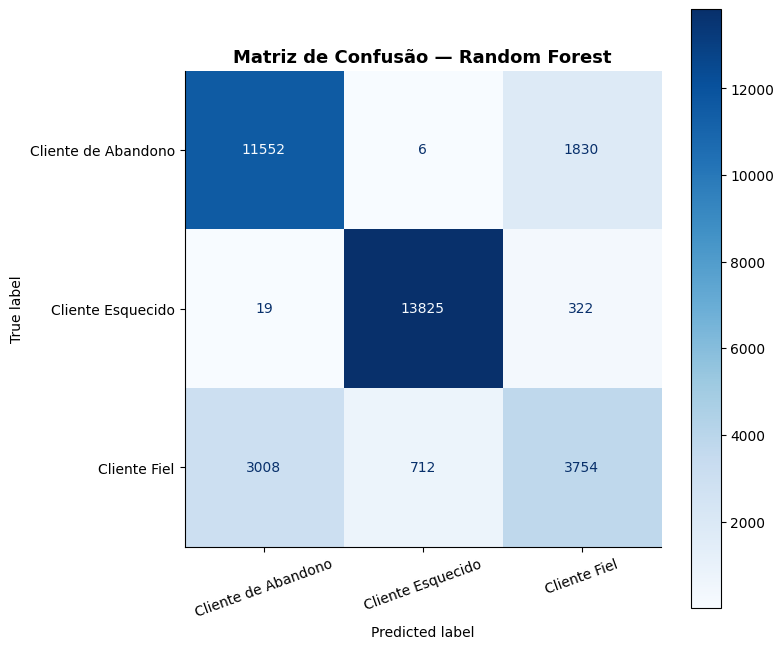

In [45]:
# Matriz de Confusão
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=target_names,
    labels=classes_presentes,
    cmap='Blues', ax=ax
)
ax.set_title("Matriz de Confusão — Random Forest", fontsize=13, fontweight='bold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("matriz_confusao.png", dpi=150, bbox_inches='tight')
plt.show()


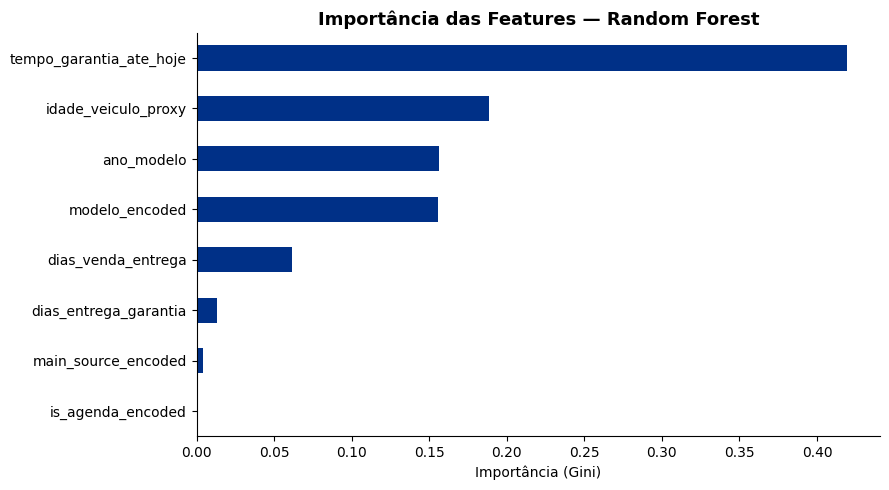


Feature mais importante: tempo_garantia_ate_hoje
Feature menos importante: is_agenda_encoded


In [46]:
# Importância das features
importances = pipe_final.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=FEATURES_COMPRA).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='barh', ax=ax, color='#003087')
ax.set_title("Importância das Features — Random Forest", fontsize=13, fontweight='bold')
ax.set_xlabel("Importância (Gini)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFeature mais importante: {feat_imp.idxmax()}")
print(f"Feature menos importante: {feat_imp.idxmin()}")


## 10. Leitura Executiva dos Resultados


In [47]:
# Resumo executivo completo
print("=" * 62)
print("        RESUMO EXECUTIVO — FORD VISION IA/ML")
print("        Grupo: Ford Vision | Turma: 3ESS | FIAP 2026")
print("=" * 62)

print("\n SEGMENTAÇÃO (Base 1 — Histórico Completo):")
total_vins = len(base1)
for perfil in ['Cliente Fiel', 'Cliente de Abandono', 'Cliente Esquecido']:
    if perfil in base1['perfil'].values:
        n = (base1['perfil'] == perfil).sum()
        pct = n / total_vins * 100
        print(f"  {perfil:25s}: {n:,} clientes ({pct:.1f}%)")

print(f"\n  Total de VINs analisados: {total_vins:,}")
print(f"  Silhouette Score:          {sil:.4f}")
print(f"  Davies-Bouldin Score:      {db:.4f}")

print("\n CLASSIFICAÇÃO (Base 2 — Dados de Compra):")
acc = accuracy_score(y_test, y_pred)
print(f"  Modelo:              Random Forest (100 estimadores)")
print(f"  Accuracy:            {acc:.4f} ({acc*100:.1f}%)")
importances = pipe_final.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=FEATURES_COMPRA).sort_values(ascending=False)
print(f"  Feature mais preditiva: {feat_imp.idxmax()} ({feat_imp.max():.4f})")

print("\n PERFIS DE MAIOR RISCO DE EVASÃO:")
for perfil in ['Cliente de Abandono', 'Cliente Esquecido']:
    if perfil in base1['perfil'].values:
        n = (base1['perfil'] == perfil).sum()
        pct = n / total_vins * 100
        print(f"  {perfil}: {n:,} clientes ({pct:.1f}%) — ação proativa recomendada")

print("\n APLICAÇÃO NO NEGÓCIO:")
print("  A solução permite que a concessionária identifique, no")
print("  momento da entrega do veículo, o perfil provável de")
print("  retenção — acionando estratégias personalizadas antes")
print("  que qualquer evasão ocorra, aumentando o VIN Share.")

print("\n DECISÕES TÉCNICAS RELEVANTES:")
print("  • K=3 adotado após K=4 gerar cluster espúrio (3 registros)")
print("  • Outliers de KM (≥1M km) removidos antes da agregação")
print("  • Data leakage evitado: Base 2 usa exclusivamente")
print("    variáveis disponíveis no momento da compra")
print("  • Silhouette/Davies-Bouldin calculados em amostra (10k)")
print("    por viabilidade computacional")


        RESUMO EXECUTIVO — FORD VISION IA/ML
        Grupo: Ford Vision | Turma: 3ESS | FIAP 2026

 SEGMENTAÇÃO (Base 1 — Histórico Completo):
  Cliente Fiel             : 37,367 clientes (21.3%)
  Cliente de Abandono      : 66,941 clientes (38.2%)
  Cliente Esquecido        : 70,829 clientes (40.4%)

  Total de VINs analisados: 175,137
  Silhouette Score:          0.4526
  Davies-Bouldin Score:      1.1122

 CLASSIFICAÇÃO (Base 2 — Dados de Compra):
  Modelo:              Random Forest (100 estimadores)
  Accuracy:            0.8316 (83.2%)
  Feature mais preditiva: tempo_garantia_ate_hoje (0.4197)

 PERFIS DE MAIOR RISCO DE EVASÃO:
  Cliente de Abandono: 66,941 clientes (38.2%) — ação proativa recomendada
  Cliente Esquecido: 70,829 clientes (40.4%) — ação proativa recomendada

 APLICAÇÃO NO NEGÓCIO:
  A solução permite que a concessionária identifique, no
  momento da entrega do veículo, o perfil provável de
  retenção — acionando estratégias personalizadas antes
  que qualquer evas

## 11. Exportação dos Resultados

In [48]:
# Exporta as bases com perfis
base1.drop(columns=['pca1','pca2'], errors='ignore').to_csv("base1_segmentada.csv", index=False)
base2.to_csv("base2_classificada.csv", index=False)

print("✅ Arquivos exportados:")
print("  • base1_segmentada.csv  — histórico completo com perfis")
print("  • base2_classificada.csv — dados de compra com perfis preditos")
print()
print("📈 Resumo final da segmentação:")
print(base1['perfil'].value_counts())


✅ Arquivos exportados:
  • base1_segmentada.csv  — histórico completo com perfis
  • base2_classificada.csv — dados de compra com perfis preditos

📈 Resumo final da segmentação:
perfil
Cliente Esquecido      70829
Cliente de Abandono    66941
Cliente Fiel           37367
Name: count, dtype: int64
